Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error

In [ ]:
dataset_filename = '/content/dual_aware_ml_dataset.csv'
print(f"Loading data from {dataset_filename}...")
try:
    df = pd.read_csv(dataset_filename)
except FileNotFoundError:
    print(f"Error: {dataset_filename} not found. Please ensure your data generation script has run.")
    df = pd.DataFrame(np.random.rand(100, 9), columns=['ve', 'vf', 'vr', 'df', 'dr', 'd_safe_f', 'd_safe_r', 'delta_df', 'u_total'])

Loading data from /content/dual_aware_ml_dataset.csv...


Define Features and Scale the Data

In [ ]:
features = ['ve',
            'vf',
            'vr',
            'df',
            'dr',
            'd_safe_f',
            'd_safe_r',
            'delta_df']
X = df[features]
y = df['u_total']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SCALE THE FEATURES (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Build and Train the Neural Network

In [ ]:
print("\nTraining the Multi-Layer Perceptron (MLP)...")
# Architecture: 2 hidden layers (64, 32) - optimized for edge hardware
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,             # L2 Regularization to prevent overfitting
    max_iter=2000,
    early_stopping=True,     # Stops if it stops improving to save time
    random_state=42
)
# Train the model
start_train = time.time()
model.fit(X_train_scaled, y_train)
end_train = time.time()
print(f"Training complete in {end_train - start_train:.2f} seconds! (Iterations: {model.n_iter_})")

# Make predictions on the unseen test set
y_pred = model.predict(X_test_scaled)


Training the Multi-Layer Perceptron (MLP)...
Training complete in 5.27 seconds! (Iterations: 168)


Evaluate and Visualize Accuracy

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print(" 1. ML ACCURACY METRICS")
print("="*40)
print(f"MSE:          {mse:.5f}")
print(f"RMSE:         {rmse:.5f} (Average magnitude of error)")
print(f"MAE:          {mae:.5f} (Average everyday deviation)")
print(f"Max Error:    {max_err:.5f} (Worst-case deviation from MPC)")
print(f"R-squared:    {r2:.5f} (Target is >0.90 for a good clone)")


 1. ML ACCURACY METRICS
MSE:          0.00135
RMSE:         0.03672 (Average magnitude of error)
MAE:          0.02231 (Average everyday deviation)
Max Error:    0.19944 (Worst-case deviation from MPC)
R-squared:    0.94795 (Target is >0.90 for a good clone)


In [ ]:
print("\n" + "="*40)
print(" 2. HARDWARE & ROBOTICS METRICS")
print("="*40)

# A. Measure Inference Speed (Latency)
# Simulate running on the robot by testing one sample at a time
single_sample = X_test_scaled[0].reshape(1, -1)
_ = model.predict(single_sample) # Warmup

start_time = time.time()
for _ in range(1000):
    _ = model.predict(single_sample)
end_time = time.time()

avg_inference_time_ms = ((end_time - start_time) / 1000) * 1000
print(f"Average Inference Latency: {avg_inference_time_ms:.4f} ms per step")
if avg_inference_time_ms < 100:
    print("  -> STATUS: PASS (Model is extremely fast, perfect for hardware)")

# B. Measure Smoothness (Jitter/Jerkiness approximation)
# Compare how drastically the AI changes its commands vs the MPC
y_test_np = np.array(y_test)
mpc_changes = np.abs(np.diff(y_test_np))
ai_changes = np.abs(np.diff(y_pred))

avg_mpc_step = np.mean(mpc_changes)
avg_ai_step = np.mean(ai_changes)

print(f"\nAvg Command Jump (Original MPC): {avg_mpc_step:.4f}")
print(f"Avg Command Jump (MLP AI):       {avg_ai_step:.4f}")

if avg_ai_step > avg_mpc_step * 1.5:
    print("  -> WARNING: AI is jittery. Consider adding a low-pass filter in C++.")
else:
    print("  -> STATUS: PASS (AI outputs are smooth and safe for motors)")


 2. HARDWARE & ROBOTICS METRICS
Average Inference Latency: 0.1456 ms per step
  -> STATUS: PASS (Model is extremely fast, perfect for hardware)

Avg Command Jump (Original MPC): 0.1706
Avg Command Jump (MLP AI):       0.1637
  -> STATUS: PASS (AI outputs are smooth and safe for motors)


Export to .npz for the Raspberry Pi

In [ ]:
print("\n" + "="*40)
print(" 3. EXPORTING MODEL FOR HARDWARE")
print("="*40)

# Extract Weights and Scaler
W1, W2, W3 = model.coefs_
b1, b2, b3 = model.intercepts_

np.savez("dual_mpc_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
np.savez("dual_mpc_scaler.npz", mean=scaler.mean_, scale=scaler.scale_)
print("Saved 'dual_mpc_weights.npz' and 'dual_mpc_scaler.npz'.")
print("Transfer these to your Raspberry Pi to run without Scikit-Learn!")


 3. EXPORTING MODEL FOR HARDWARE
Saved 'dual_mpc_weights.npz' and 'dual_mpc_scaler.npz'.
Transfer these to your Raspberry Pi to run without Scikit-Learn!


Visualization

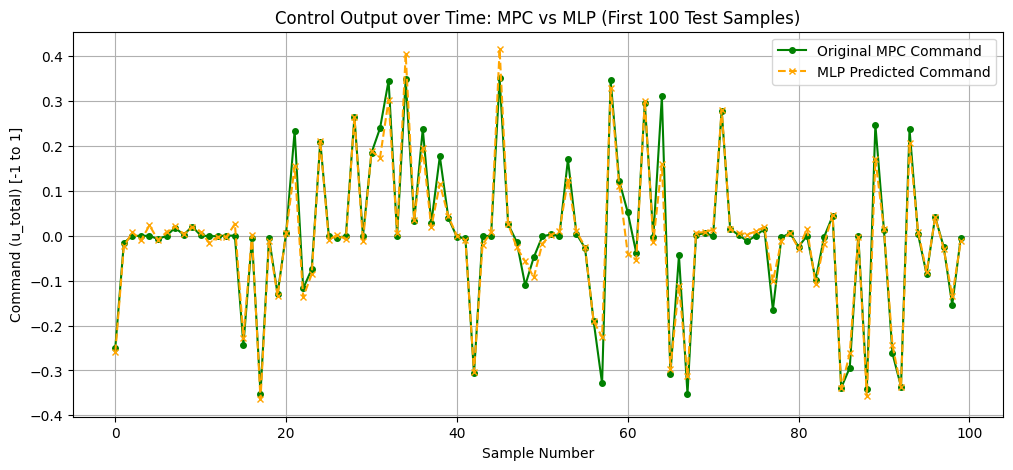

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_np[:100], label='Original MPC Command', color='green', marker='o', markersize=4)
plt.plot(y_pred[:100], label='MLP Predicted Command', color='orange', linestyle='--', marker='x', markersize=4)
plt.title('Control Output over Time: MPC vs MLP (First 100 Test Samples)')
plt.xlabel('Sample Number')
plt.ylabel('Command (u_total) [-1 to 1]')
plt.legend()
plt.grid(True)
plt.show()